In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import sympy as sp 
from IPython.display import display, Math

## Defining the Variables 

In [2]:
x = np.array([1,2,3,4])
y = np.array([1,5,11,8])

## Plotting the Variables 

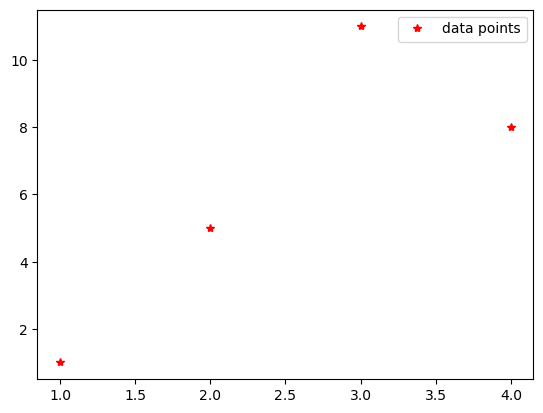

In [3]:
plt.plot(x,y,"r*", label="data points")
plt.legend()

Given $M_{0}$ = $M_{3}$ = 0  
so $h_{i}$ = 1, as $x_{i+1}$ - $x_{i}$  
interioer continuity equation are for i = 1,2  

$M_{i-1}$ + $4M_{i}$ + $M_{i+1}$ = $\frac{6}{h^2}$ ($f_{i+1}$ - $2f_{i}$ + $f_{i-1}$)  

$M_{0}$ + $4M_{1}$ + $M_{2}$ = $\frac{6}{h^2}$ ($f_{2}$ - $2f_{1}$ + $f_{0}$)  

$M_{1}$ + $4M_{2}$ + $M_{3}$ = $\frac{6}{h^2}$ ($f_{3}$ - $2f_{2}$ + $f_{1}$) 

so unknown $M_{1}$ and $M_{2}$ which we will get from  
$(n - 1)$ X $(n-1)$ = $(3-1)$ X $(3-1)$ = $2$ X $2$ diagonal system  

$$
\begin{pmatrix} 
4 & 1 \\
1 & 4  
\end{pmatrix}

\begin{pmatrix} 
M_{1} \\
M_{2} 
\end{pmatrix}
=
\begin{pmatrix}
12 \\
-54
\end{pmatrix}
$$


In [4]:
def cubic_spline_M(x,y):
    n = len(x) - 1
    h =x[1] - x[0]

    right_hand_side = np.zeros(n-1)
    for i in range (1, n):
        right_hand_side[i-1] = (6/(h**2)) * ((y[i+1]) - (2*y[i]) + (y[i-1]))

    # for tridiagonal matrix 
    A = np.zeros((n-1, n-1))
    for i in range(n-1):
        A[i,i] = 4
        if i>0:
            A[i,i-1] = 1
        if i< n-2:
            A[i,i+1] = 1 

    # solving for M 
    M_values = np.linalg.solve(A, right_hand_side)

    M = np.zeros(n+1)
    M[1:n] = M_values

    return M 

print(cubic_spline_M(x,y))

[  0.    6.8 -15.2   0. ]


using the values of $M$ in equation  

$F(x)$ = $\frac{1}{6h}$ $[(x_{i} - x)^3 M_{i-1} + (x-x_{i-1})^3 M_{i}]$ + $\frac{1}{h}$ $(x_{i} - x)$ $(f_{i-1} - \frac{h^2}{6} M_{i-1})$ + $\frac{1}{h}$ $(x - x_{i-1})$ $(f_{i} - \frac{h^2}{6}M_{i})$

In [5]:
def symbolic_cubic_spline(a, x, y, M = cubic_spline_M(x,y)):
    a_sym = sp.Symbol(str(a))
    #a_sdiff = sp.Symbol(str(a_diff))
    xi_minus1, xi = sp.symbols('x1_minus1 xi') 
    yi_minus1, yi = sp.symbols('yi_minus1 yi')
    Mi_minus1, Mi = sp.symbols('Mi_minus1 Mi')
    h = sp.symbols('h')

    spline_equation = (
        ((xi - a_sym)**3 * Mi_minus1 + (a_sym - xi_minus1)**3 * Mi)/(6*h)
        + ((xi - a_sym)/h) * (yi_minus1 - (h**2 / 6) * Mi_minus1)
        + ((a_sym - xi_minus1) / h) * (yi - (h**2 / 6) * Mi)        
        )
    
    #display(Math(sp.latex(spline_equation)))

    spline_derivative = sp.diff(spline_equation, a_sym)
    for i in range(1, len(x)):
        if x[i-1] <= a <= x[i]:
            substitute = {
                xi_minus1 : x[i-1],
                xi : x[i], 
                yi_minus1 : y[i-1],
                yi : y[i],
                Mi_minus1 : M[i-1], 
                Mi : M[i],
                h : x[i] - x[i-1],
            }
            #Substituting the values into the expression 
            Spline_value = spline_equation.subs(substitute).subs(a_sym, a).evalf()
            Spline_derivative_value = spline_derivative.subs(substitute).subs(a_sym, a).evalf()
            return float(Spline_value), float(Spline_derivative_value)
    raise ValueError(F"Value {a} is outside the interpolation range ")


x_value = 1.5 
y_value , y_prime_value = symbolic_cubic_spline(x_value, x, y)

print(f"y({x_value}) = {y_value}")
#print(f"y'({x_value}) = {y_prime_value}")



x_value = 2
y_value , y_prime_value = symbolic_cubic_spline(x_value, x, y)

#print(f"y({x_value}) = {y_value}")
print(f"y'({x_value}) = {y_prime_value}")

y(1.5) = 2.5749999999999997
y'(2) = 6.266666666666666


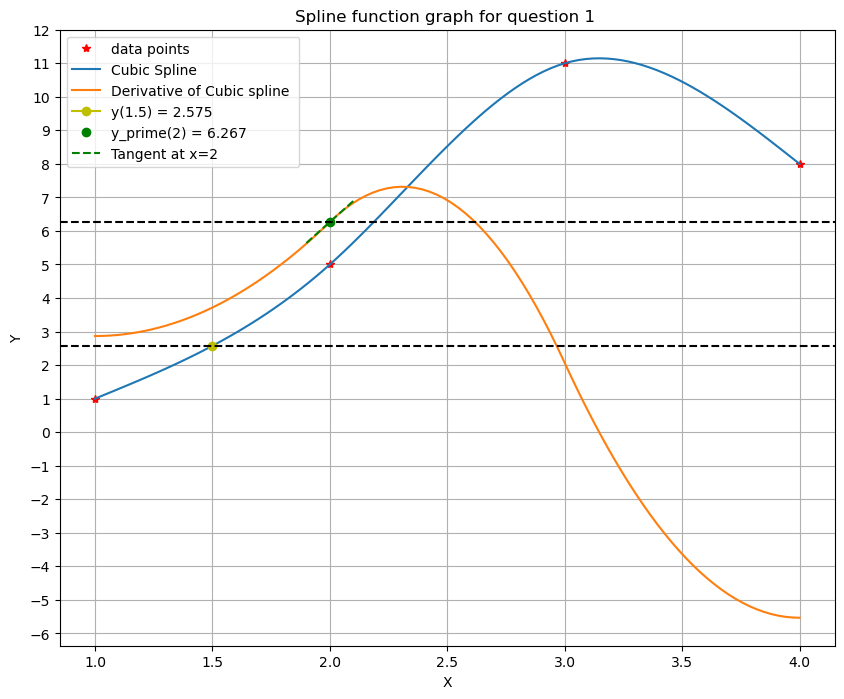

In [6]:
x_dense = np.linspace(x[0], x[-1], 100)
y_dense = [symbolic_cubic_spline(a, x, y)[0] for a in x_dense]
y_dense_derivative = [symbolic_cubic_spline(a, x, y)[1] for a in x_dense]

x_point = 2
y_point, y_prime_point = symbolic_cubic_spline(x_point, x, y)

x_point1 = 1.5
y_point1, y_prime_point1 = symbolic_cubic_spline(x_point1, x, y)
plt.figure (figsize=(10,8))

y_min, y_max = -6, 12
x_min, x_max = 1,4

# Create ticks
yticks = np.linspace(y_min, y_max, 19)
xticks = np.linspace(x_min, x_max, 7)

plt.plot(x,y,"r*", label="data points")
plt.plot(x_dense, y_dense, label = "Cubic Spline ")
plt.plot(x_dense, y_dense_derivative, label = "Derivative of Cubic spline ")
plt.plot(x_point1, y_point1, '-yo', label=f'y({x_point1}) = {y_point1:.3f}')
plt.plot(x_point, y_prime_point, 'go', label = f'y_prime({x_point}) = {y_prime_point:.3f}')
plt.axhline(y=y_prime_point, color='black', linestyle='--', linewidth=1.5)
plt.axhline(y=y_point1, color='black', linestyle='--', linewidth=1.5)

delta = 0.1 
x_tangent = np.linspace(x_point - delta, x_point + delta, 30 )
y_tangent = y_prime_point + y_prime_point * (x_tangent - x_point)

plt.plot(x_tangent , y_tangent, 'g--' , label = f"Tangent at x={x_point}")


plt.yticks(yticks)
plt.xticks(xticks)
plt.title("Spline function graph for question 1 ")
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid()
plt.show ()